# 05 — Explainability: SHAP (Albania 2022)

Global and local explanations for the LightGBM model on the Albania 2022 cohort. LightGBM is fit fresh in this kernel (boosters alone are OpenMP-safe), so SHAP runs live.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # macOS duplicate OpenMP guard
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
import shap
from src.models.prepare import build_model_data, impute_median
from src.models.registry import get_model
from src.explainability.shap_analysis import compute_shap_values, global_feature_importance

df = pd.read_parquet('../data/processed/alb_2022.parquet')
feats = ['ESCS','HOMEPOS','GENDER','REPEAT','IMMIG','BELONG','TEACHSUP',
         'ICTHOME','ICTSCH','ANXMAT','GRADE','HISCED','HISEI']
data = build_model_data(df, feats, domain='math')
(X,) = impute_median(data.X); y = data.y.values
model = get_model('lightgbm'); model.fit(X, y, sample_weight=data.weights.values)
print('trained on', X.shape)

2026-06-29 18:34:30 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.0


2026-06-29 18:34:30 [info     ] Removing correlated feature    feature=SES_COMPLETE threshold=0.97


2026-06-29 18:34:30 [info     ] Feature selection complete     n_features=20


2026-06-29 18:34:30 [info     ] Model data built               at_risk_rate=0.7536 domain=math n_features=20 n_samples=6129 target_col=AT_RISK_MATH


trained on (6129, 20)


## 1. Global feature importance (mean |SHAP|)

In [3]:
shap_vals, names = compute_shap_values(model, X,
        X_background=X.sample(min(300, len(X)), random_state=42), max_samples=2000)
imp = global_feature_importance(shap_vals, names)
imp

2026-06-29 18:34:31 [info     ] Subsampling for SHAP           original=6129 sampled=2000


2026-06-29 18:34:31 [info     ] Using TreeSHAP                 model_type=LGBMClassifier


2026-06-29 18:34:31 [info     ] SHAP values computed           shape=(2000, 20)


,feature,mean_abs_shap,rank
0,HOMEPOS,0.319407,1
1,ANXMAT,0.312796,2
2,HISCED,0.275390,3
3,HISEI,0.208977,4
4,DIGITAL_READINESS,0.193165,5
5,ESCS,0.181871,6
6,BELONG,0.173567,7
7,TEACHSUP,0.143565,8
8,MATERIAL_DEFICIT,0.124417,9
9,BELONG_x_TEACHSUP,0.120374,10


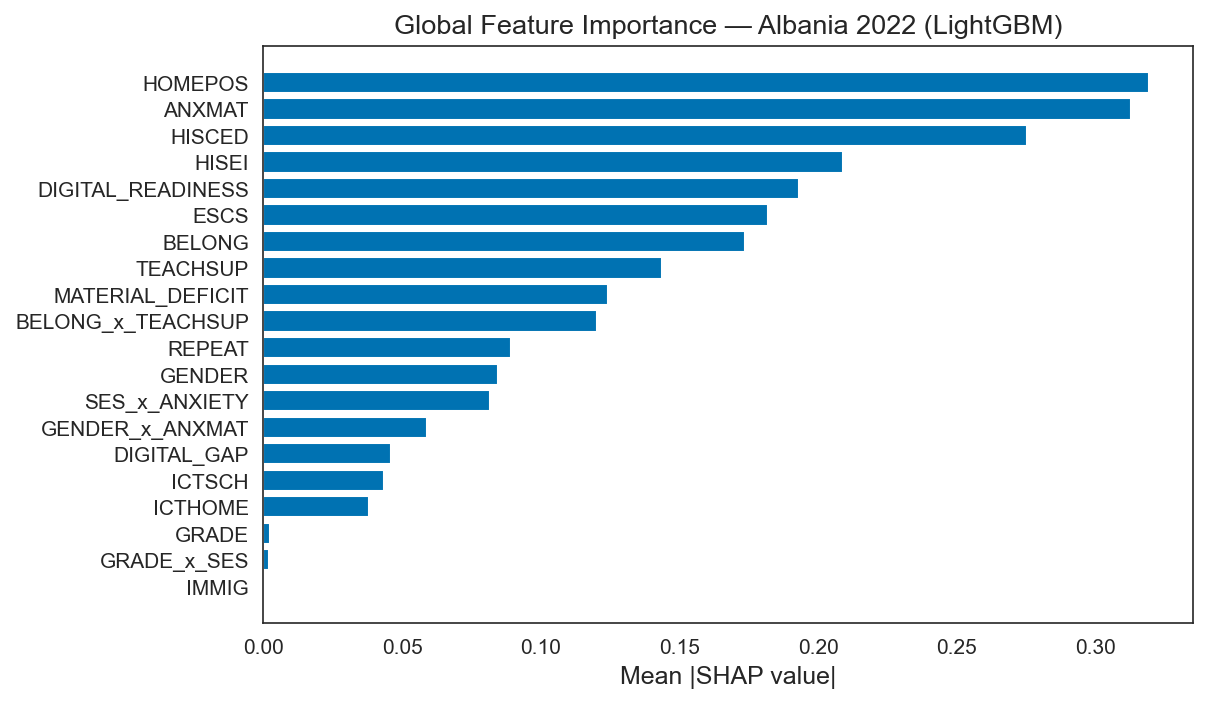

In [4]:
from src.visualization.style import apply_publication_style
apply_publication_style()
imp_s = imp.sort_values('mean_abs_shap')
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(imp_s['feature'], imp_s['mean_abs_shap'], color='#0072B2')
ax.set_xlabel('Mean |SHAP value|'); ax.set_title('Global Feature Importance — Albania 2022 (LightGBM)')
plt.show()

**Reading:** `HOMEPOS` (home possessions) and `ANXMAT` (math anxiety) dominate, followed by parental education/occupation (`HISCED`, `HISEI`) and digital readiness. Immigration status and grade deviation contribute almost nothing.

## 2. SHAP beeswarm — direction of effects

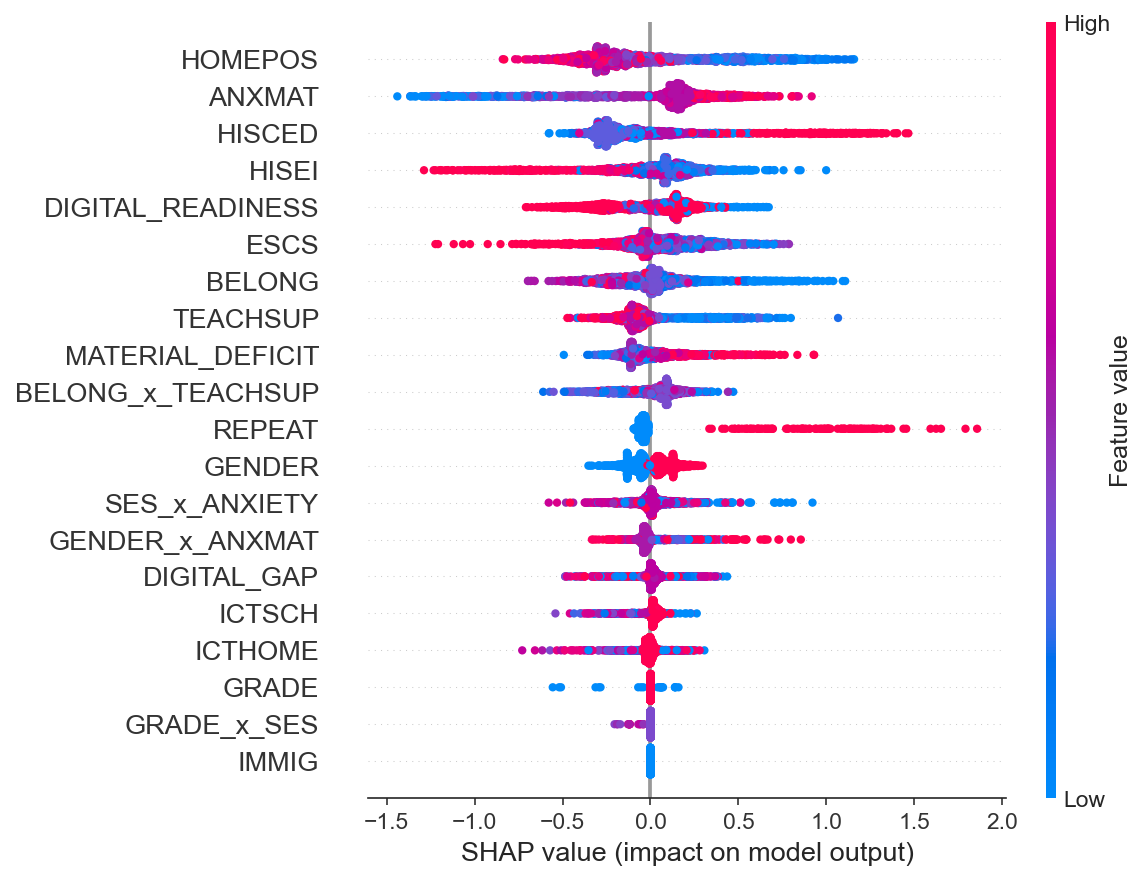

In [5]:
X_s = X.sample(min(2000, len(X)), random_state=42).reset_index(drop=True)
shap.summary_plot(shap_vals, X_s[names], show=True, plot_size=(8,6))

## 3. SHAP dependence — does SES moderate math anxiety?

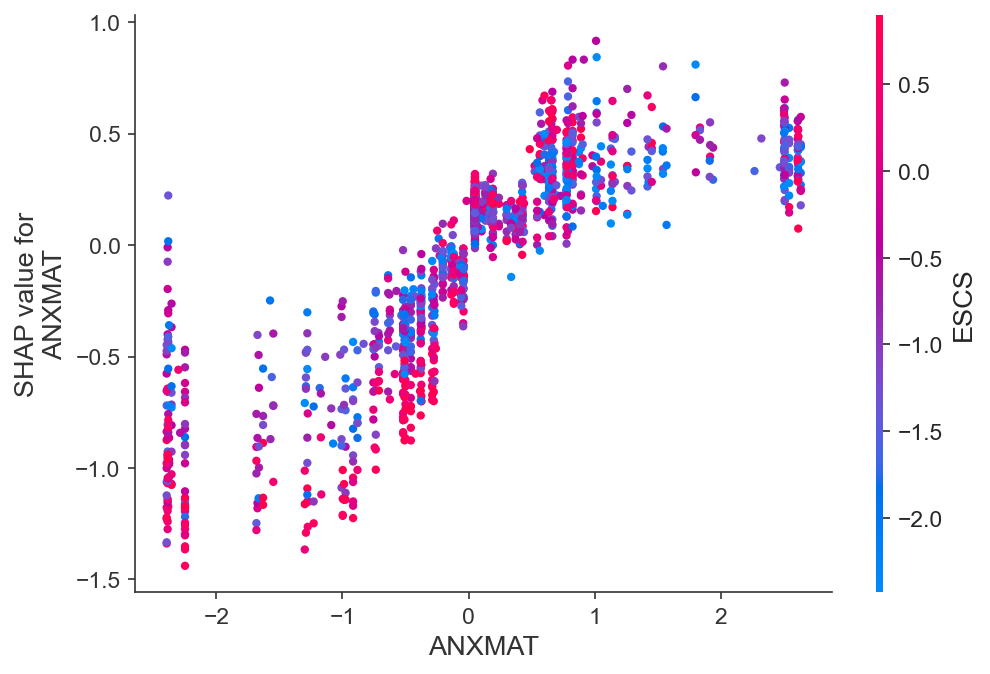

In [6]:
if 'ANXMAT' in names and 'ESCS' in names:
    shap.dependence_plot('ANXMAT', shap_vals, X_s[names], interaction_index='ESCS', show=True)

**Interpretation:** higher math anxiety pushes predictions toward at-risk; the colouring shows whether socioeconomic status buffers or amplifies that effect — a policy-relevant interaction.